In [5]:
path = '../Thesis_Data/'

In [ ]:
import pandas as pd
df = pd.read_csv(path+'Final_Data/Final_Merged_Data.csv')
# df_sample = pd.read_csv('../Thesis_Data/Final_Data/sample_data.csv')


## S matrix construction

In [2]:
import numpy as np
import pandas as pd
from scipy.sparse import lil_matrix, csr_matrix

# Get unique identifiers
animals = df[['Farm_Code', 'Animal_ID']].drop_duplicates().reset_index(drop=True)
farms   = df['Farm_Code'].unique()

n_animals = len(animals)          # 81,144  — bottom level
n_farms   = len(farms)            # 315
n_total   = 1
n_series  = n_animals + n_farms + n_total   # 81,460

# Index mappings
animal_to_idx = {row['Animal_ID']: i for i, row in animals.iterrows()}
farm_to_idx   = {f: n_animals + i for i, f in enumerate(farms)}
total_idx     = n_animals + n_farms   # last row

# Build S matrix (rows = all series, cols = bottom-level animals)
S = lil_matrix((n_series, n_animals), dtype=np.float32)

# Bottom level — identity block
for i in range(n_animals):
    S[i, i] = 1.0

# Farm level — each farm row sums its animals
for _, row in animals.iterrows():
    animal_idx = animal_to_idx[row['Animal_ID']]
    farm_idx   = farm_to_idx[row['Farm_Code']]
    S[farm_idx, animal_idx] = 1.0

# Total level — sums everything
S[total_idx, :] = 1.0

# Convert to CSR for efficient arithmetic
S = csr_matrix(S)

print(f"S matrix shape: {S.shape}")
print(f"Non-zero elements: {S.nnz:,}")
print(f"Density: {S.nnz / (S.shape[0] * S.shape[1]) * 100:.4f}%")

S matrix shape: (81442, 81127)
Non-zero elements: 243,381
Density: 0.0037%


## Saving HS

In [7]:
import scipy.sparse as sp

# Save cleaned dataframe
df.to_parquet(path+'HS/buffalo_cleaned.parquet', index=False)

# Save S matrix
sp.save_npz(path+'HS/S_matrix.npz', S)

# Save index mappings for later reconstruction
animals.to_parquet(path+'HS/animal_index.parquet', index=False)
pd.Series(farm_to_idx).to_json(path+'HS/farm_index.json')

print("All saved ✅")

All saved ✅


## DIM grid (biologically natural)
Each animal's series is indexed 1–365 DIM, with gaps where no test occurred. 

### Define the DIM grid

In [8]:
import numpy as np

# Monthly grid: midpoints of 30-day windows
# 15, 45, 75, ..., 345 → 12 points covering 0–365 DIM
DIM_GRID = np.arange(15, 365, 30)  # [15, 45, 75, ..., 345]
print(f"Grid points: {DIM_GRID}")
print(f"Number of grid points: {len(DIM_GRID)}")  # 12

Grid points: [ 15  45  75 105 135 165 195 225 255 285 315 345]
Number of grid points: 12


### Snap each record to nearest grid point

In [9]:
def snap_to_grid(dim_value, grid=DIM_GRID):
    """Assign each DIM value to the nearest grid point."""
    idx = np.argmin(np.abs(grid - dim_value))
    return grid[idx]

df['DIM_grid'] = df['DIM'].apply(snap_to_grid)

# Check: how many animals have duplicate grid points
# (two tests fell in the same 30-day window)
duplicates = df.groupby(['Animal_ID', 'DIM_grid']).size()
print(f"Total (animal, grid_point) pairs: {len(duplicates):,}")
print(f"Pairs with >1 record: {(duplicates > 1).sum():,}")
print(f"Percentage: {(duplicates > 1).sum() / len(duplicates) * 100:.2f}%")

Total (animal, grid_point) pairs: 579,456
Pairs with >1 record: 88,538
Percentage: 15.28%


### Resolve duplicates (two tests in same window)

In [10]:
# For duplicates, take the mean of milk_kg and protein_p
df_grid = (
    df.groupby(['Farm_Code', 'Animal_ID', 'DIM_grid'])
    [['milk_kg', 'protein_p']]
    .mean()
    .reset_index()
)

print(f"Records after grid snapping: {len(df_grid):,}")
print(f"Animals: {df_grid['Animal_ID'].nunique():,}")

Records after grid snapping: 579,477
Animals: 81,119


#### Build full grid per animal (with NaN for missing points)

In [11]:
from itertools import product

# Create complete grid skeleton: every animal × every DIM grid point
all_animals = df_grid[['Farm_Code', 'Animal_ID']].drop_duplicates()
grid_df = pd.DataFrame(
    [(row.Farm_Code, row.Animal_ID, dim)
     for _, row in all_animals.iterrows()
     for dim in DIM_GRID],
    columns=['Farm_Code', 'Animal_ID', 'DIM_grid']
)

# Merge actual values onto full grid
df_full = grid_df.merge(df_grid, on=['Farm_Code', 'Animal_ID', 'DIM_grid'], how='left')

print(f"Full grid shape: {df_full.shape}")
print(f"Missing milk_kg: {df_full['milk_kg'].isna().sum():,} ({df_full['milk_kg'].isna().mean()*100:.1f}%)")
print(f"Missing protein_p: {df_full['protein_p'].isna().sum():,} ({df_full['protein_p'].isna().mean()*100:.1f}%)")

Full grid shape: (973524, 5)
Missing milk_kg: 394,047 (40.5%)
Missing protein_p: 394,047 (40.5%)


## Implement Wood's curve interpolation

In [31]:
from scipy.optimize import curve_fit
from scipy.stats import zscore
import warnings
from scipy.optimize import OptimizeWarning

warnings.filterwarnings('ignore', category=OptimizeWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

def woods_curve(dim, a, b, c):
    return a * np.power(dim, b) * np.exp(-c * dim)

def fit_woods_robust(animal_df, target_col, grid=DIM_GRID):
    observed = animal_df.dropna(subset=[target_col]).copy()
    
    if len(observed) < 3:
        return pd.Series(np.nan, index=grid)
    
    dim_obs = observed['DIM_grid'].values
    y_obs   = observed[target_col].values
    
    # Remove outliers using z-score (|z| > 2.5)
    if len(y_obs) >= 4:
        z = np.abs(zscore(y_obs))
        mask = z < 2.5
        if mask.sum() >= 3:  # only apply if enough points remain
            dim_obs = dim_obs[mask]
            y_obs   = y_obs[mask]
    
    try:
        p0 = [y_obs.mean(), 0.1, 0.003]
        params, _ = curve_fit(
            woods_curve, dim_obs, y_obs,
            p0=p0,
            bounds=([0, 0, 0], [np.inf, 2, 0.1]),
            maxfev=5000
        )
        predicted = woods_curve(grid, *params)
        predicted = np.clip(predicted, 0, None)
        return pd.Series(predicted, index=grid)
    
    except Exception:
        return pd.Series(
            np.interp(grid, dim_obs, y_obs),
            index=grid
        )

# Apply per animal — this will take a few minutes on 81K animals
results_milk    = []
results_protein = []

grouped = df_full.groupby(['Farm_Code', 'Animal_ID'])
total   = len(grouped)

for i, ((farm, animal), grp) in enumerate(grouped):
    if i % 5000 == 0:
        print(f"Processing {i:,}/{total:,}...")
    
    milk_pred    = fit_woods_robust(grp, 'milk_kg')
    protein_pred = fit_woods_robust(grp, 'protein_p')
    
    results_milk.append({
        'Farm_Code': farm,
        'Animal_ID': animal,
        **{f'dim_{d}': v for d, v in milk_pred.items()}
    })
    results_protein.append({
        'Farm_Code': farm,
        'Animal_ID': animal,
        **{f'dim_{d}': v for d, v in protein_pred.items()}
    })

df_milk    = pd.DataFrame(results_milk)
df_protein = pd.DataFrame(results_protein)

print(f"\nMilk tensor shape:    {df_milk.shape}")
print(f"Protein tensor shape: {df_protein.shape}")
print(f"Remaining NaNs milk:    {df_milk.filter(like='dim_').isna().sum().sum():,}")
print(f"Remaining NaNs protein: {df_protein.filter(like='dim_').isna().sum().sum():,}")

Processing 0/81,127...
Processing 5,000/81,127...
Processing 10,000/81,127...
Processing 15,000/81,127...
Processing 20,000/81,127...
Processing 25,000/81,127...
Processing 30,000/81,127...
Processing 35,000/81,127...
Processing 40,000/81,127...
Processing 45,000/81,127...
Processing 50,000/81,127...
Processing 55,000/81,127...
Processing 60,000/81,127...
Processing 65,000/81,127...
Processing 70,000/81,127...
Processing 75,000/81,127...
Processing 80,000/81,127...

Milk tensor shape:    (81127, 14)
Protein tensor shape: (81127, 14)
Remaining NaNs milk:    2,352
Remaining NaNs protein: 2,352


In [32]:
dim_cols = [c for c in df_milk.columns if c.startswith('dim_')]

# Step 1: Drop biologically impossible rows (negative or near-zero milk)
valid_milk = (df_milk[dim_cols] > 0.1).all(axis=1)
valid_prot = (df_protein[dim_cols] > 0.01).all(axis=1)
valid_both = valid_milk & valid_prot

df_milk    = df_milk[valid_both].reset_index(drop=True)
df_protein = df_protein[valid_both].reset_index(drop=True)

print(f"Animals after removing invalid curves: {len(df_milk):,}")
print(f"Dropped: {(~valid_both).sum():,}")

# Step 2: Verify zero NaNs remain
print(f"Remaining NaNs milk:    {df_milk[dim_cols].isna().sum().sum()}")
print(f"Remaining NaNs protein: {df_protein[dim_cols].isna().sum().sum()}")

# Step 3: Save clean tensors
df_milk.to_parquet('milk_tensor.parquet', index=False)
df_protein.to_parquet('protein_tensor.parquet', index=False)
print("Saved ✅")

Animals after removing invalid curves: 79,972
Dropped: 1,155
Remaining NaNs milk:    0
Remaining NaNs protein: 0
Saved ✅


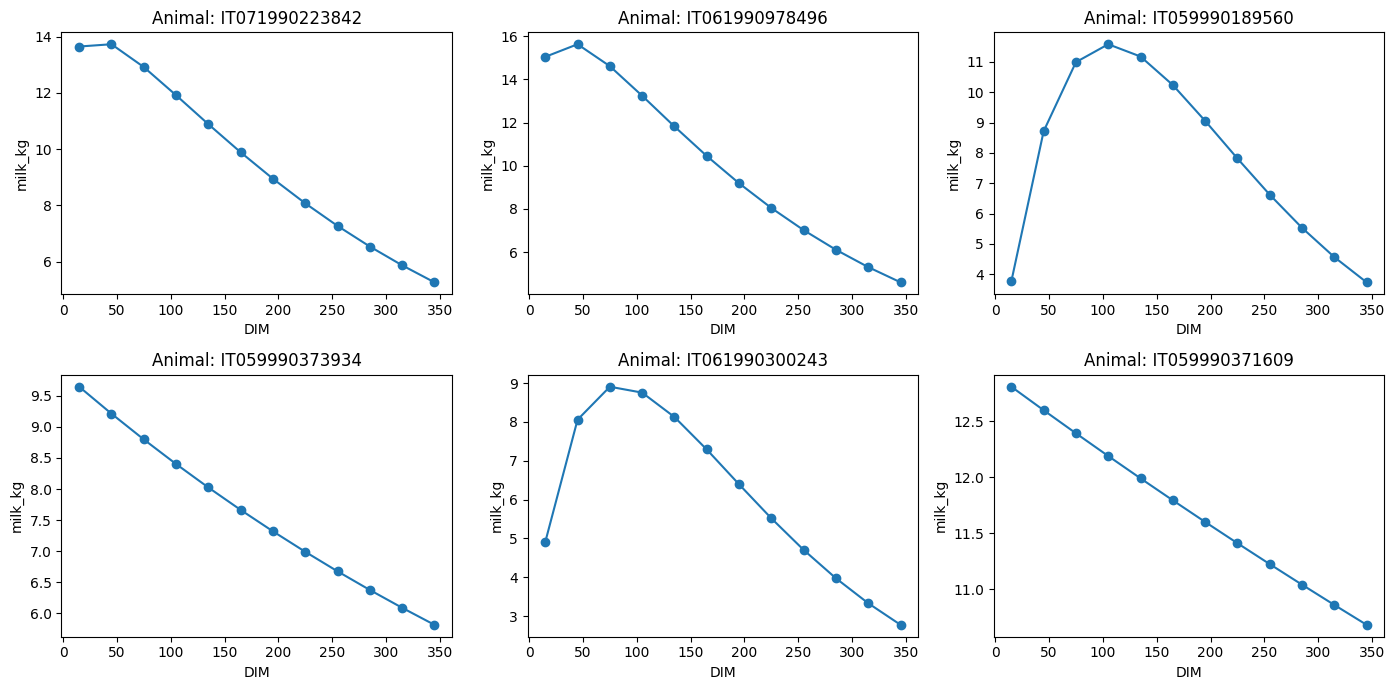

Plot saved ✅


In [33]:
import matplotlib.pyplot as plt

# Plot 6 random animal lactation curves for visual inspection
sample = df_milk.sample(6, random_state=42)
grid_points = [int(c.split('_')[1]) for c in dim_cols]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    ax.plot(grid_points, row[dim_cols].values, marker='o')
    ax.set_title(f"Animal: {row['Animal_ID']}")
    ax.set_xlabel('DIM')
    ax.set_ylabel('milk_kg')
plt.tight_layout()
plt.savefig('lactation_curves_sample.png', dpi=150)
plt.show()
print("Plot saved ✅")

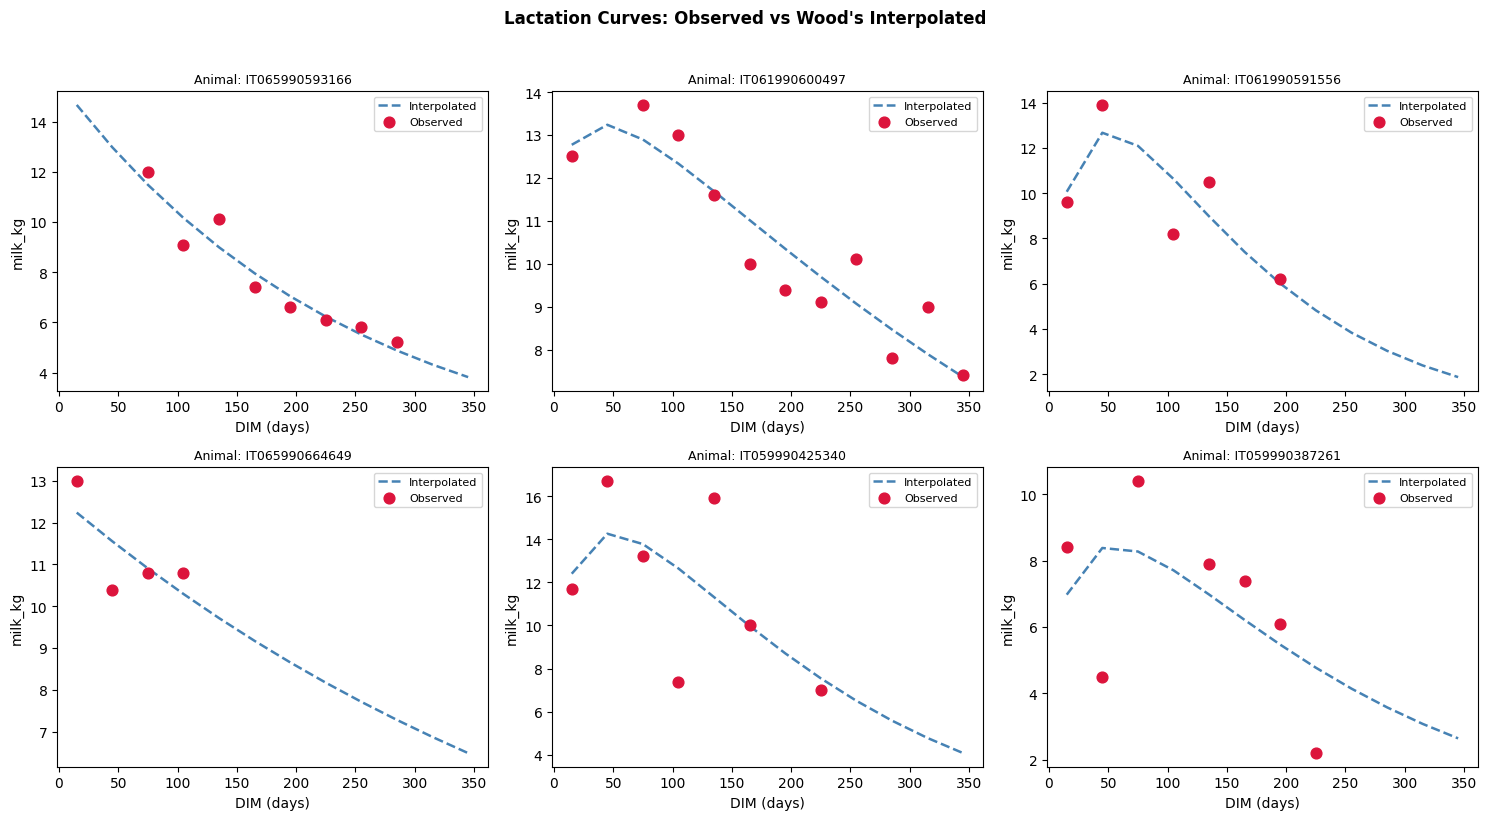

Saved ✅


In [36]:
import matplotlib.pyplot as plt
import numpy as np

dim_cols    = [c for c in df_milk.columns if c.startswith('dim_')]
grid_points = [int(c.split('_')[1]) for c in dim_cols]

# Get original observed grid points per animal (before Wood's fill)
# df_grid is the snapped-but-not-filled dataframe from earlier
# If you don't have it in memory, reload:
# df_grid = df_full.dropna(subset=['milk_kg'])  ← from before the Wood's step

sample_animals = df_milk.sample(6, random_state=100)['Animal_ID'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, animal_id in zip(axes.flatten(), sample_animals):
    # Full interpolated curve
    row = df_milk[df_milk['Animal_ID'] == animal_id].iloc[0]
    farm = row['Farm_Code']
    y_full = row[dim_cols].values

    # Actual observed points (from original snapped data)
    observed = df_grid[
        (df_grid['Animal_ID'] == animal_id)
    ][['DIM_grid', 'milk_kg']].dropna()

    # Plot interpolated line
    ax.plot(grid_points, y_full,
            color='steelblue', linewidth=1.8,
            linestyle='--', label='Interpolated')

    # Overlay actual observations
    ax.scatter(observed['DIM_grid'], observed['milk_kg'],
               color='crimson', zorder=5, s=60, label='Observed')

    ax.set_title(f"Animal: {animal_id}", fontsize=9)
    ax.set_xlabel('DIM (days)')
    ax.set_ylabel('milk_kg')
    ax.legend(fontsize=8)

plt.suptitle("Lactation Curves: Observed vs Wood's Interpolated", 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('lactation_curves_observed_vs_interpolated.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

In [37]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
from scipy.optimize import OptimizeWarning, curve_fit
from scipy.stats import zscore

warnings.filterwarnings('ignore', category=OptimizeWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

def woods_curve(dim, a, b, c):
    return a * np.power(dim, b) * np.exp(-c * dim)

fit_results = []

grouped = df_full.groupby(['Farm_Code', 'Animal_ID'])
total   = len(grouped)

for i, ((farm, animal), grp) in enumerate(grouped):
    if i % 5000 == 0:
        print(f"Processing {i:,}/{total:,}...")

    for target in ['milk_kg', 'protein_p']:
        observed = grp.dropna(subset=[target]).copy()

        if len(observed) < 3:
            continue

        dim_obs = observed['DIM_grid'].values
        y_obs   = observed[target].values

        # Outlier rejection
        if len(y_obs) >= 4:
            z    = np.abs(zscore(y_obs))
            mask = z < 2.5
            if mask.sum() >= 3:
                dim_obs = dim_obs[mask]
                y_obs   = y_obs[mask]

        try:
            p0     = [y_obs.mean(), 0.1, 0.003]
            params, _ = curve_fit(
                woods_curve, dim_obs, y_obs,
                p0=p0,
                bounds=([0, 0, 0], [np.inf, 2, 0.1]),
                maxfev=5000
            )
            y_pred = woods_curve(dim_obs, *params)
            y_pred = np.clip(y_pred, 0, None)

            r2   = r2_score(y_obs, y_pred)
            rmse = np.sqrt(mean_squared_error(y_obs, y_pred))
            mae  = mean_absolute_error(y_obs, y_pred)

            fit_results.append({
                'Farm_Code': farm,
                'Animal_ID': animal,
                'target':    target,
                'n_obs':     len(y_obs),
                'a':         params[0],
                'b':         params[1],
                'c':         params[2],
                'R2':        r2,
                'RMSE':      rmse,
                'MAE':       mae,
                'fit_method': 'woods'
            })

        except Exception:
            # Record failed fits
            fit_results.append({
                'Farm_Code':  farm,
                'Animal_ID':  animal,
                'target':     target,
                'n_obs':      len(y_obs),
                'a':          np.nan,
                'b':          np.nan,
                'c':          np.nan,
                'R2':         np.nan,
                'RMSE':       np.nan,
                'MAE':        np.nan,
                'fit_method': 'linear_fallback'
            })

df_fits = pd.DataFrame(fit_results)
df_fits.to_parquet('woods_fit_quality.parquet', index=False)
print("Saved ✅")

Processing 0/81,127...
Processing 5,000/81,127...
Processing 10,000/81,127...
Processing 15,000/81,127...
Processing 20,000/81,127...
Processing 25,000/81,127...
Processing 30,000/81,127...
Processing 35,000/81,127...
Processing 40,000/81,127...
Processing 45,000/81,127...
Processing 50,000/81,127...
Processing 55,000/81,127...
Processing 60,000/81,127...
Processing 65,000/81,127...
Processing 70,000/81,127...
Processing 75,000/81,127...
Processing 80,000/81,127...
Saved ✅


In [38]:
print("=" * 50)
print("WOOD'S CURVE FIT QUALITY REPORT")
print("=" * 50)

for target in ['milk_kg', 'protein_p']:
    sub = df_fits[
        (df_fits['target'] == target) & 
        (df_fits['fit_method'] == 'woods')
    ]
    
    print(f"\n--- {target} ---")
    print(f"Animals fitted (Wood's):   {len(sub):,}")
    print(f"Fallback (linear):         {(df_fits['target']==target).sum() - len(sub):,}")
    print(f"\nR²   — mean: {sub['R2'].mean():.3f}  "
          f"median: {sub['R2'].median():.3f}  "
          f"std: {sub['R2'].std():.3f}")
    print(f"RMSE — mean: {sub['RMSE'].mean():.3f}  "
          f"median: {sub['RMSE'].median():.3f}  "
          f"std: {sub['RMSE'].std():.3f}")
    print(f"MAE  — mean: {sub['MAE'].mean():.3f}  "
          f"median: {sub['MAE'].median():.3f}  "
          f"std: {sub['MAE'].std():.3f}")
    print(f"\nR² distribution:")
    print(f"  R² < 0:      {(sub['R2'] < 0).sum():,}  (poor fits)")
    print(f"  0 ≤ R² < 0.5:{((sub['R2'] >= 0) & (sub['R2'] < 0.5)).sum():,}  (weak)")
    print(f"  0.5 ≤ R² < 0.8:{((sub['R2'] >= 0.5) & (sub['R2'] < 0.8)).sum():,}  (acceptable)")
    print(f"  R² ≥ 0.8:    {(sub['R2'] >= 0.8).sum():,}  (good)")

WOOD'S CURVE FIT QUALITY REPORT

--- milk_kg ---
Animals fitted (Wood's):   80,931
Fallback (linear):         0

R²   — mean: -41637013409.144  median: 0.778  std: 11845053419881.484
RMSE — mean: 1.079  median: 0.984  std: 0.646
MAE  — mean: 0.887  median: 0.809  std: 0.530

R² distribution:
  R² < 0:      303  (poor fits)
  0 ≤ R² < 0.5:17,532  (weak)
  0.5 ≤ R² < 0.8:25,576  (acceptable)
  R² ≥ 0.8:    37,520  (good)

--- protein_p ---
Animals fitted (Wood's):   80,931
Fallback (linear):         0

R²   — mean: 0.373  median: 0.318  std: 0.312
RMSE — mean: 0.237  median: 0.223  std: 0.125
MAE  — mean: 0.200  median: 0.189  std: 0.106

R² distribution:
  R² < 0:      4,040  (poor fits)
  0 ≤ R² < 0.5:48,713  (weak)
  0.5 ≤ R² < 0.8:17,647  (acceptable)
  R² ≥ 0.8:    10,531  (good)


In [40]:
# Replace mean with median in your thesis table
# And flag poor fits for transparency

df_fits['fit_quality'] = pd.cut(
    df_fits['R2'],
    bins=[-np.inf, 0, 0.5, 0.8, 1.0],
    labels=['poor', 'weak', 'acceptable', 'good']
)

# Thesis-ready summary table
summary = df_fits.groupby(['target', 'fit_quality']).size().unstack(fill_value=0)
print(summary)

# Save
df_fits.to_parquet('woods_fit_quality.parquet', index=False)

# Print clean thesis table
print("\n=== THESIS TABLE — Wood's Curve Fit Quality ===")
print(f"{'Metric':<12} {'milk_kg':>12} {'protein_p':>12}")
print("-" * 38)
for metric, col in [('Median R²','R2'), ('Median RMSE','RMSE'), ('Median MAE','MAE')]:
    mk = df_fits[df_fits['target']=='milk_kg'][col].median()
    pr = df_fits[df_fits['target']=='protein_p'][col].median()
    print(f"{metric:<12} {mk:>12.3f} {pr:>12.3f}")

/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_97921/2679320618.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_fits.groupby(['target', 'fit_quality']).size().unstack(fill_value=0)


fit_quality  poor   weak  acceptable   good
target                                     
milk_kg       373  17462       25576  37520
protein_p    4863  47890       17647  10531

=== THESIS TABLE — Wood's Curve Fit Quality ===
Metric            milk_kg    protein_p
--------------------------------------
Median R²           0.778        0.318
Median RMSE         0.984        0.223
Median MAE          0.809        0.189
